In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

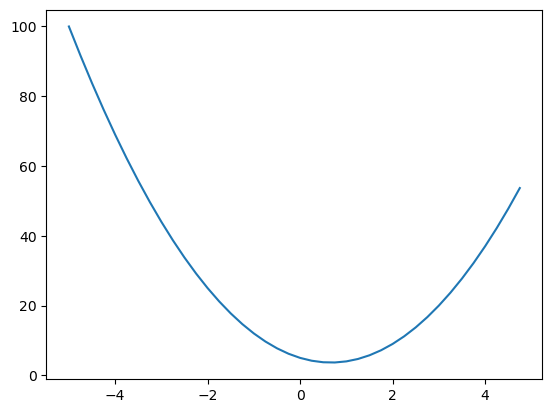

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
ys
plt.plot(xs,ys)

In [5]:
h = 1e-6
x = 3.0

# derivative of x
# dx = (f(x+h) - f(x))/h 
# limit as h approaches 0 of  ( f(x+h) - f(x) ) / h

# should be 3 * x^2 - 4*x + 5
#           3 * 2x  - 4
#           6x  - 4
#           6*3 - 4 == 14 if x: 3

In [6]:
x = 2/3
dx = (f(x+h)-f(x))/h
print(dx)

2.999378523327323e-06


In [7]:
# lets write our own expression
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
d

4.0

In [8]:
# lets figure out how to find the derivative.
# derivative of d with respect to a
h = 1e-6 # define a small change
a = 2.0
b = -3.0
c = 10.0

d1 = a*b+c
a += h
d2 = a*b+c

print('d1',d1)
print('d2',d2)
print('slope', (d2-d1)/h)

# By inspection though, da/dd (a*b+c) -> b -> (((drop a and +c))) == -3.0

d1 4.0
d2 3.9999969999999996
slope -3.000000000419334


In [9]:
# derivative of d with respect to b
h = 1e-6
a = 2.0
b = -3.0
c = 10.0
d1 = a*b+c
b += h
d2 = a*b+c
print('d1',d1)
print('d2',d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.000002
slope 2.000000000279556


In [10]:
# derivative of d with respect to c
h = 1e-6
a = 2.0
b = -3.0
c = 10.0
d1 = a*b+c
c += h
d2 = a*b+c
print('d1',d1)
print('d2',d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.000000999999999
slope 0.9999999992515995


In [11]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, rhs):
        out = Value(self.data + rhs.data, (self, rhs), '+')
        def _backward():
            self.grad = 1.0 * out.grad
            rhs.grad = 1.0 * out.grad
            
        out._backward = _backward
        return out
        
    def __mul__(self, rhs):
        out = Value(self.data * rhs.data, (self, rhs), '*')
        def _backward():
            self.grad = rhs.data * out.grad
            rhs.grad = self.data * out.grad
        out._backward = _backward
        return out

    def __lt__(self, rhs):
        return self.data < rhs.data

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad = (1 - (t**2) ) * out.grad
        out._backward = _backward
        return out



In [12]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
print(d._prev)
print(d._op)

{Value(data=-6.0), Value(data=10.0)}
+


In [13]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a * b + c
listd = sorted(list(d._prev))
print(listd)

[Value(data=-6.0), Value(data=10.0)]


In [14]:
def debugValues(value):
    if value.data is None:
        return 0
    print(value._prev)
    print(value._op)
    for v in value._prev:
        debugValues(v)



In [15]:
debugValues(d)

{Value(data=-6.0), Value(data=10.0)}
+
{Value(data=-3.0), Value(data=2.0)}
*
set()

set()

set()



In [16]:
# pip3 install graphviz
from graphviz import Digraph

In [17]:

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    #print('nodes:',nodes)
    #print('edges:',edges)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        #print('creating node ',n)
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % ( n.label, n.data, n.grad ), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        #print('creating edge between ', n1, n2)
        #print('string id of n1: ', str(id(n1)))
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot
    


In [18]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'


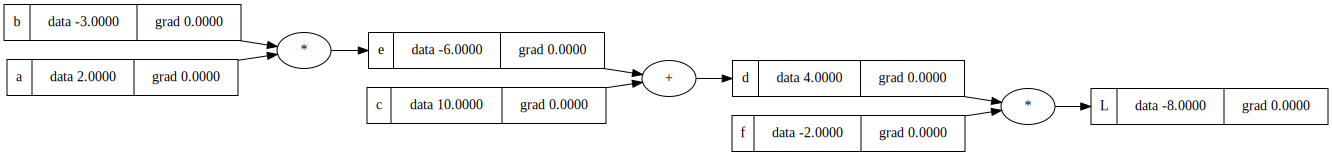

In [19]:
draw_dot(L)

In [20]:
# Find the derivatives manually. Starting from L and working backwards.
# Just make sure to add 'h' to the value you want to get the partial derivative for.

def verify_derivative():
    h = 1e-4
    
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    
    L1 = L.data

    a = Value(2.0 + h, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2-L1)/h)
verify_derivative()
# 6.0 for a
# 1.0 for L
# -2 for d
# 4 for f
# dL/dc = dL/dd * dd/dc   (chain rule)  == -2.0 * 1.0  ; dd/de => 1.0 also

6.000000000021544


In [21]:
# manually set the derivatives (grads)
a.grad = 6.0
b.grad = -4.0
e.grad = -2.0
c.grad = -2.0
d.grad = -2.0
f.grad = 4.0
L.grad = 1.0

In [22]:
# manually adding weights
# we can add a small weight to leaf nodes.
# leaf nodes: a, b, c, f
wei = 0.01
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad


In [23]:
# manually running a forward pass
Lbefore = L
print('L before: ', Lbefore)
e = a * b
d = e + c
L = d * f
print('L: ', L)


L before:  Value(data=-8.0)
L:  Value(data=-7.286496)


In [24]:
# added tanh to Value
# Implementing a neuron (two dimensional neuron b/c 1d is too simple)
# as pictured in https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Ftse2.mm.bing.net%2Fth%2Fid%2FOIP.bISf27J9cSxdawMd8BVRswHaD5%3Fr%3D0%26pid%3DApi&f=1&ipt=f5447b728d49b209821c9567ecfc78f2dd9b6dece41444ef68ba5feca2de6519&ipo=images
#   summing_function = Sum ( X_ij * W_ij ) + b
#   where: X is input, W is weight, b is bias
#   activation_function = tanh(summing_function())

y1 = Value(2.0, label='y1')
y2 = Value(0.0, label='y2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = bias = Value(6.881373, label='b')
# Sum(Yn+Wn) + b
y1w1 = y1*w1; y1w1.label = 'y1w1'
y2w2 = y2*w2; y2w2.label = 'y2w2'
y1w1y2w2 = y1w1 + y2w2; y1w1y2w2.label = 'y1w1y2w2'
n = y1w1y2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'


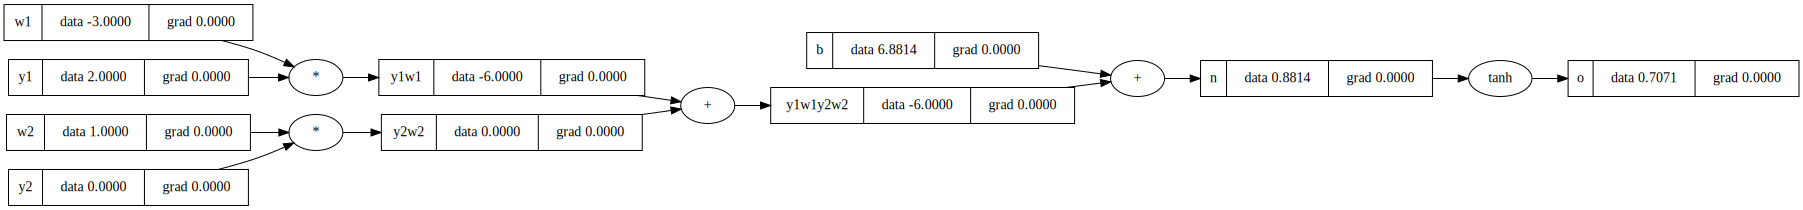

In [25]:
draw_dot(o)

In [26]:
# here we go, calculate all the derivatives.

# do/dw1
# do/dy1
# do/dy2
# do/dw2
# do/y1w1y2w2
# do/y1w1
# do/y2w2 
# do/db
# do/dn START HERE and go up

o.grad = 1.0 # o = tanh(n) 
# derivative of tanh(x):    1 - tanh^2(x)  == 1 - ( tanh(x) * tanh(x) )
# therefore
# do/dn = 1 - ( tanh(n) * tanh(n) ) 
# do/dn = 1 - ( 0.7071 * 0.7071) =
dodn = 1 - (o.data * o.data) # 0.500000041508
n.grad = 0.5

# do/db == dn/db * do/dn == dn/db * 0.5 == 1 * 0.5 == 0.5
b.grad = 0.5
# since its a plus, y1w1y2w2 grad is also 0.5
y1w1y2w2.grad = 0.5

# the next one is a + relationship too, therefore 0.5 backprops to y1w1 and y2w2
y1w1.grad = 0.5
y2w2.grad = 0.5

# we might be able to do the rest dy2, dw2, dy1, dw1 by inspection...
y2.grad = 0.5 # 1 * 0.5
w2.grad = 0.0 # 0 * 0.5

y1.grad = -1.5 # -3.0 * 0.5
w1.grad = 1.0  # 2 * 0.5


In [27]:
# Implement backpropagation with _backward() function in Value

# base case, set o.grad to 1.0
o.grad = 1.0
o._backward()



In [28]:
n._backward()

In [29]:
y1w1y2w2._backward()

In [30]:
y1w1._backward()

In [31]:
y2w2._backward()

In [32]:
# stop calling _backward() manually by traversing function backward.
# do a topological-sort to get the DAG from left to right.
topo = []
Visited = set()
def build_topo(v):
    if v not in Visited:
        Visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[Value(data=6.881373),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=0.881373),
 Value(data=0.7071064876766542)]

In [33]:
# restart and use this topo graph instead.
y1 = Value(2.0, label='y1')
y2 = Value(0.0, label='y2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = bias = Value(6.881373, label='b')
# Sum(Yn+Wn) + b
y1w1 = y1*w1; y1w1.label = 'y1w1'
y2w2 = y2*w2; y2w2.label = 'y2w2'
y1w1y2w2 = y1w1 + y2w2; y1w1y2w2.label = 'y1w1y2w2'
n = y1w1y2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

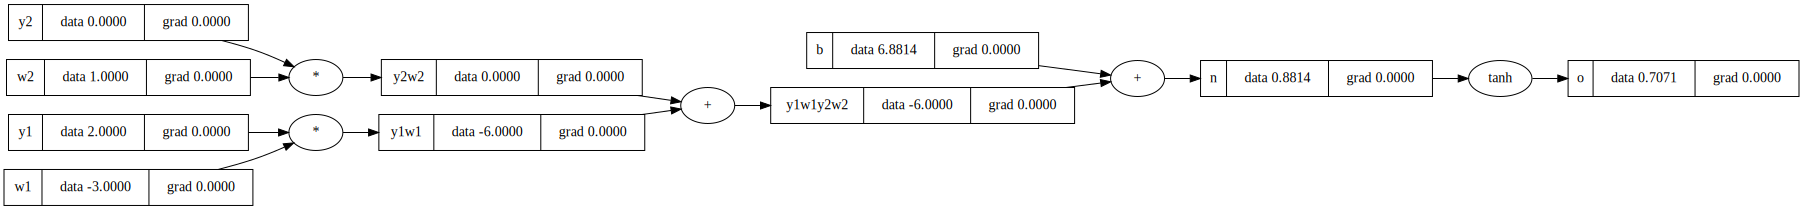

In [34]:
draw_dot(o)

In [35]:
o.grad = 1.0

In [36]:
for node in reversed(topo):
    node._backward()

In [37]:
# add this to the Value class itself.
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, rhs):
        out = Value(self.data + rhs.data, (self, rhs), '+')
        def _backward():
            self.grad = 1.0 * out.grad
            rhs.grad = 1.0 * out.grad
            
        out._backward = _backward
        return out
        
    def __mul__(self, rhs):
        out = Value(self.data * rhs.data, (self, rhs), '*')
        def _backward():
            self.grad = rhs.data * out.grad
            rhs.grad = self.data * out.grad
        out._backward = _backward
        return out

    def __lt__(self, rhs):
        return self.data < rhs.data

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad = (1 - (t**2) ) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        Visited = set()
        def build_topo(v):
            if v not in Visited:
                Visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()



In [38]:
# test it out again using the class function instead:

# restart and use this topo graph instead.
y1 = Value(2.0, label='y1')
y2 = Value(0.0, label='y2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = bias = Value(6.881373, label='b')
# Sum(Yn+Wn) + b
y1w1 = y1*w1; y1w1.label = 'y1w1'
y2w2 = y2*w2; y2w2.label = 'y2w2'
y1w1y2w2 = y1w1 + y2w2; y1w1y2w2.label = 'y1w1y2w2'
n = y1w1y2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

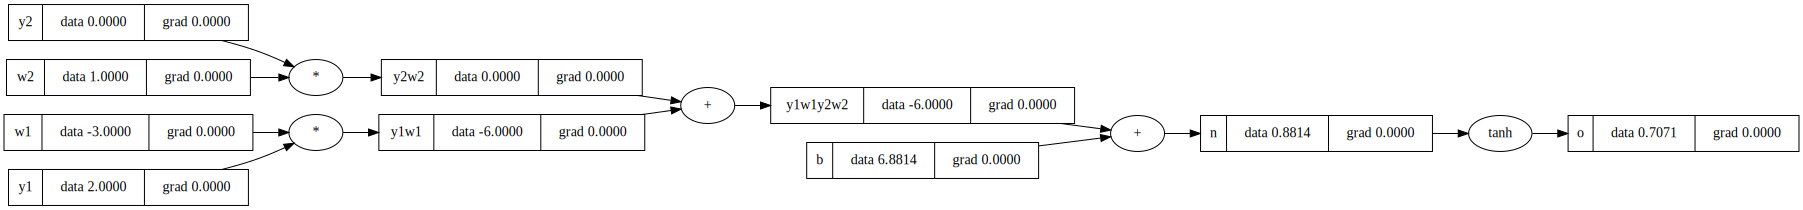

In [39]:
draw_dot(o)

In [40]:
o.backward()

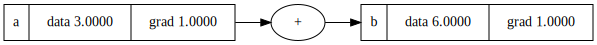

In [41]:
# fix this bug
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)
#  a grad should not be 1.0, it should be 2.0
# fix: use '+=' instead of '=' for the _backward methods.

In [42]:
# fixed
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, rhs):
        rhs = rhs if isinstance(rhs, Value) else Value(rhs)
        out = Value(self.data + rhs.data, (self, rhs), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            rhs.grad += 1.0 * out.grad
            
        out._backward = _backward
        return out
        
    def __mul__(self, rhs):
        rhs = rhs if isinstance(rhs, Value) else Value(rhs)
        out = Value(self.data * rhs.data, (self, rhs), '*')
        def _backward():
            self.grad += rhs.data * out.grad
            rhs.grad += self.data * out.grad
        out._backward = _backward
        return out

    # Pythonism to handle noClass * Class multiplication.
    def __rmul__(self, rhs): # rhs * self
        return self * rhs

    def __lt__(self, rhs):
        return self.data < rhs.data

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - (t**2) ) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        Visited = set()
        def build_topo(v):
            if v not in Visited:
                Visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()



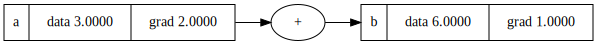

In [43]:
# fix this bug
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)
#  a grad should not be 1.0, it should be 2.0
# fix: use '+=' instead of '=' for the _backward methods.

Value(data=7.38905609893065)


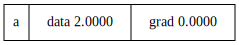

In [44]:
# a = Value(2)
# 2 * a wont work
# impl __rmul__() on Value
# define exp() on Value
a = Value(2.0, label = 'a')
print(a.exp())
draw_dot(a)

In [45]:
# define division in Value
# fixed
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, rhs):
        rhs = rhs if isinstance(rhs, Value) else Value(rhs)
        out = Value(self.data + rhs.data, (self, rhs), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            rhs.grad += 1.0 * out.grad
            
        out._backward = _backward
        return out
        
    def __mul__(self, rhs):
        rhs = rhs if isinstance(rhs, Value) else Value(rhs)
        out = Value(self.data * rhs.data, (self, rhs), '*')
        def _backward():
            self.grad += rhs.data * out.grad
            rhs.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, x):
        assert isinstance(x, (int, float)), "only supporting int/float powers"
        # todo: Maybe impl ability to do Value ** Value
        out = Value(self.data**x, (self, ), f'**{x}')
        def _backward():
            self.grad += ((self.data*x)**(x-1)) * out.grad
            self.grad += x * (self.data ** (x - 1)) * out.grad
        out._backward = _backward
        return out

    # Pythonism to handle noClass * Class multiplication.
    def __rmul__(self, rhs): # rhs * self
        return self * rhs

    def __lt__(self, rhs): # for sorting
        return self.data < rhs.data

    def __truediv__(self, x): # self / other
        # a / b == a * 1/b == a * b**-1
        return self * (x ** -1)

    def __neg__(self):
        return self * -1

    def __sub__(self, x):
        return self + (-x)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - (t**2) ) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        Visited = set()
        def build_topo(v):
            if v not in Visited:
                Visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()



In [46]:
a = Value(2)
b = 4.0
a ** b
#  2^3 == 2 * 2^2 == 2 * 4 == 8


Value(data=16.0)

In [47]:
# test it out again using the class function instead:

# restart and use this topo graph instead.
y1 = Value(2.0, label='y1')
y2 = Value(0.0, label='y2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = bias = Value(6.881373, label='b')
# Sum(Yn+Wn) + b
y1w1 = y1*w1; y1w1.label = 'y1w1'
y2w2 = y2*w2; y2w2.label = 'y2w2'
y1w1y2w2 = y1w1 + y2w2; y1w1y2w2.label = 'y1w1y2w2'
n = y1w1y2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

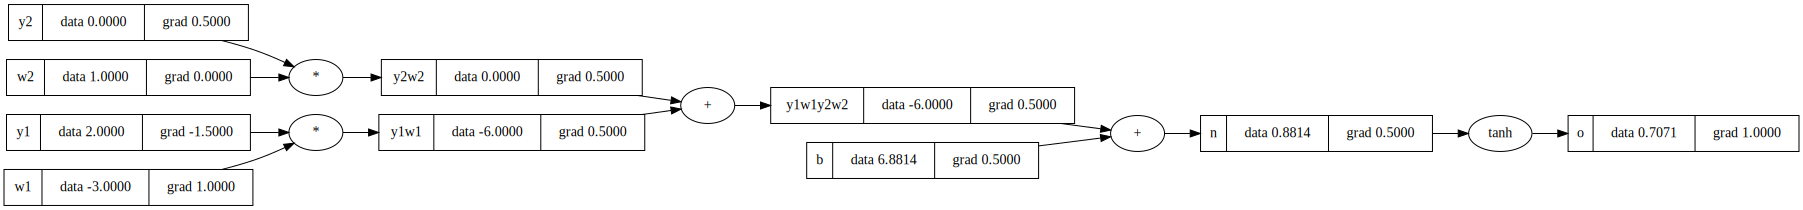

In [48]:
draw_dot(o)

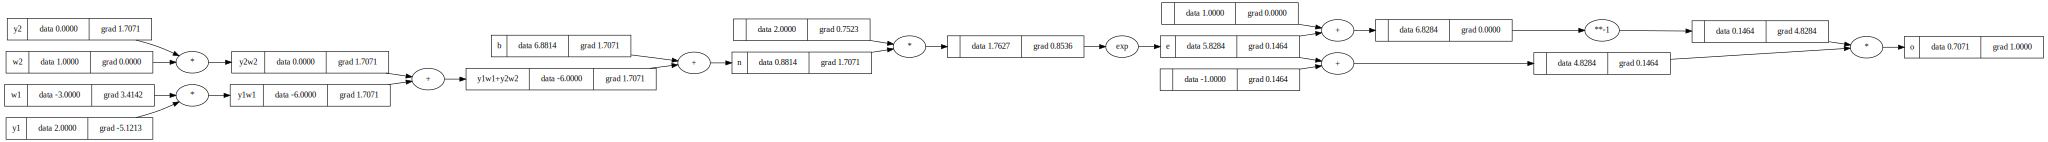

In [49]:
# breaking the tanh into the exponent expression
y1 = Value(2.0, label='y1')
y2 = Value(0.0, label='y2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = bias = Value(6.881373, label='b')
# Sum(Yn+Wn) + b
y1w1 = y1*w1; y1w1.label = 'y1w1'
y2w2 = y2*w2; y2w2.label = 'y2w2'
y1w1y2w2 = y1w1 + y2w2; y1w1y2w2.label = 'y1w1+y2w2'
n = y1w1y2w2 + b; n.label = 'n'

e = (2*n).exp(); e.label = 'e'
o = (e - 1) / (e + 1)

o.label = 'o'
o.backward()
draw_dot(o)
# Note: my gradiants did not match because my __pow__ _backward() method was busted
# og:  self.grad += ((self.data * x) ** (x-1)) * out.grad  
# fix: self.grad += x * (self.data ** (x - 1)) * out.grad
# was accidentally computing the multiplication BEFORE the power. 
# Parenthesis (self.data * x) messed up the calc.

In [50]:
# Torchy's Tacos

import torch
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.88137358670195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
print(o.item())
o.backward()
print('-------')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())
# OUTPUT:
# 0.7071066904050358
# 0.7071066904050358
# -------
# x2 0.5000001283844369
# w2 0.0
# x1 -1.5000003851533106
# w1 1.0000002567688737

0.7071066904050358
0.7071066904050358
-------
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [51]:
o

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)

In [52]:
import random
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, rhs):
        rhs = rhs if isinstance(rhs, Value) else Value(rhs)
        out = Value(self.data + rhs.data, (self, rhs), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            rhs.grad += 1.0 * out.grad
            
        out._backward = _backward
        return out
        
    def __mul__(self, rhs):
        rhs = rhs if isinstance(rhs, Value) else Value(rhs)
        out = Value(self.data * rhs.data, (self, rhs), '*')
        def _backward():
            self.grad += rhs.data * out.grad
            rhs.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, x):
        assert isinstance(x, (int, float)), "only supporting int/float powers"
        # todo: Maybe impl ability to do Value ** Value
        out = Value(self.data**x, (self, ), f'**{x}')
        def _backward():
            self.grad += ((self.data*x)**(x-1)) * out.grad
            self.grad += x * (self.data ** (x - 1)) * out.grad
        out._backward = _backward
        return out

    # Pythonism to handle noClass * Class multiplication.
    def __rmul__(self, rhs): # rhs * self
        return self * rhs

    def __lt__(self, rhs): # for sorting
        return self.data < rhs.data

    def __truediv__(self, x): # self / other
        # a / b == a * 1/b == a * b**-1
        return self * (x ** -1)

    def __neg__(self):
        return self * -1

    def __sub__(self, x):
        return self + (-x)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - (t**2) ) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        Visited = set()
        def build_topo(v):
            if v not in Visited:
                Visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


In [53]:
# This was the code I needed to update to fix the error documented at end of the cell
import math
import random
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, rhs):
        rhs = rhs if isinstance(rhs, Value) else Value(rhs)
        out = Value(self.data + rhs.data, (self, rhs), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            rhs.grad += 1.0 * out.grad
            
        out._backward = _backward
        return out
        
    def __mul__(self, rhs):
        rhs = rhs if isinstance(rhs, Value) else Value(rhs)
        out = Value(self.data * rhs.data, (self, rhs), '*')
        def _backward():
            self.grad += rhs.data * out.grad
            rhs.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, x):
        assert isinstance(x, (int, float)), "only supporting int/float powers"
        # todo: Maybe impl ability to do Value ** Value
        out = Value(self.data**x, (self, ), f'**{x}')
        def _backward():
            self.grad += ((self.data*x)**(x-1)) * out.grad
            self.grad += x * (self.data ** (x - 1)) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - (t**2) ) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        Visited = set()
        def build_topo(v):
            if v not in Visited:
                Visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
            
    def __lt__(self, rhs): # for sorting
        return self.data < rhs.data

    #----
    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"
# impl a Neuron w/ pytorch
class Neuron:
    def __init__(self, N):
        self.w = [Value(random.uniform(-1,1)) for _ in range(N)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        print(self.w)
        print(x)
        for wi,xi in zip(self.w, x):
            print('wi: ', wi)
            print('xi: ', xi)
        
        multiples = [wi*xi for wi,xi in zip(self.w, x)]
        print('multiples: ', multiples)
        fake_sum = multiples[0] + multiples[1]
        print('fake sum: ', fake_sum)
        res = 0
        for m in multiples:
            res += m
        print('res: ', res)
        sum_multiples = sum(multiples)
        out = sum_multiples + self.b
        return out

x = [2.0, 3.0]
n = Neuron(2)
n
n(x)
# Getting errors, need to fix Value.

# ---------------------------------------------------------------------------
# TypeError                                 Traceback (most recent call last)
# Cell In[54], line 30
#      28 n = Neuron(2)
#      29 n
# ---> 30 n(x)
#      31 # Getting errors, need to fix Value.
# 
# Cell In[54], line 21, in Neuron.__call__(self, x)
#      19 res = 0
#      20 for m in multiples:
# ---> 21     res += m
#      22 print('res: ', res)
#      23 sum_multiples = sum(multiples)
# 
# TypeError: unsupported operand type(s) for +=: 'int' and 'Value'

## NOTE: I do not like errors in my notebooks, so i am fixing it here, but saving this error for posterity.

[Value(data=-0.9612336049107808, grad=0.0), Value(data=0.8164621725573236, grad=0.0)]
[2.0, 3.0]
wi:  Value(data=-0.9612336049107808, grad=0.0)
xi:  2.0
wi:  Value(data=0.8164621725573236, grad=0.0)
xi:  3.0
multiples:  [Value(data=-1.9224672098215616, grad=0.0), Value(data=2.4493865176719707, grad=0.0)]
fake sum:  Value(data=0.5269193078504091, grad=0.0)
res:  Value(data=0.5269193078504091, grad=0.0)


Value(data=0.10390164511386324, grad=0.0)

In [54]:
# I just needed to implement __radd__ to Value
class Neuron:
    def __init__(self, N):
        self.w = [Value(random.uniform(-1,1)) for _ in range(N)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        raw = sum([wi*xi for wi,xi in zip(self.w, x)], self.b)
        # print('raw: ', raw)
        # activation function
        out = raw.tanh()
        return out

    def __repr__(self):
        return f"Neuron(w={self.w},b={self.b})"

class Layer:
    # N: number of inputs
    # M: number of neurons in a single layer
    def __init__(self, N, M: int):
        self.neurons = [Neuron(N) for _ in range(M)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs

class MLP:
    # M: list of number of neurons in each layer
    #    defines the sizes of all the layers
    def __init__(self, N, M: list(), dbg = False):
        sz = [N] + M
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(M))]
        if dbg:
            print('sz: ', sz)
            print('len layers: ', len(self.layers))
#        l[0] = L[sz[0], sz[1]] == L(3, 4)
#        l[1] = L(4, 4)
#        l[2] = L(4, 1)

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
        
    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"

        
# x = [2.0, 3.0]
# n = Neuron(2)
# n(x)

In [63]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1], dbg=True)
n(x)

# inputs (3 x 4), our Neural net takes 3 inputs, and yields 1 output
xs = [                # desired output
    [2.0, 3.0, -1.0], # -> 1.0
    [3.0, -1.0, 0.5], # -> -1.0
    [0.5, 1.0, 1.0],  # -> -1.0
    [1.0, 1.0, -1.0], # -> 1.0
]

# desired targets
ys = [1.0, -1.0, -1.0, 1.0] 

ypred = [n(x) for x in xs]
ypred

sz:  [3, 4, 4, 1]
len layers:  3


[Value(data=0.7313232892494805, grad=0.0),
 Value(data=0.24297633992857703, grad=0.0),
 Value(data=0.7930103214641355, grad=0.0),
 Value(data=0.5240058104200038, grad=0.0)]

In [154]:
# I just needed to implement __radd__ to Value
# then later i needed to change Layer __call__ return types
class Neuron:
    def __init__(self, N):
        self.w = [Value(random.uniform(-1,1)) for _ in range(N)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        raw = sum([wi*xi for wi,xi in zip(self.w, x)], self.b)
        # print('raw: ', raw)
        # activation function
        out = raw.tanh()
        return out

    def __repr__(self):
        return f"Neuron(w={self.w},b={self.b})"

    def parameters(self):
        return self.w + [self.b]

class Layer:
    # N: number of inputs
    # M: number of neurons in a single layer
    def __init__(self, N, M: int):
        self.neurons = [Neuron(N) for _ in range(M)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs # fixed here

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
#        out = []
#        for neuron in self.neurons:
#            out.extend(neuron.parameters())
#            return out

class MLP:
    # M: list of number of neurons in each layer
    #    defines the sizes of all the layers
    def __init__(self, N, M: list(), dbg = False):
        sz = [N] + M
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(M))]
        if dbg:
            print('sz: ', sz)
            print('len layers: ', len(self.layers))
#        l[0] = L[sz[0], sz[1]] == L(3, 4)
#        l[1] = L(4, 4)
#        l[2] = L(4, 1)

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
        
    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

        
# x = [2.0, 3.0]
# n = Neuron(2)
# n(x)


# for ygt,yout in zip(ys, ypred):
#     print(ygt, type(ygt))
#     print('\t',yout, type(yout))
#     sub = yout-ygt
#     print('sub:',sub)
#     sq == sub**2
#     print('sq:', sq)
    
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1], dbg=True)
n(x)

# inputs (3 x 4), our Neural net takes 3 inputs, and yields 1 output
xs = [                # desired output
    [2.0, 3.0, -1.0], # -> 1.0
    [3.0, -1.0, 0.5], # -> -1.0
    [0.5, 1.0, 1.0],  # -> -1.0
    [1.0, 1.0, -1.0], # -> 1.0
]

# desired targets
ys = [1.0, -1.0, -1.0, 1.0] 

ypred = [n(x) for x in xs]
ypred

zz =  [(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]
loss = sum(zz)
print('loss:', loss)
zz

# Error saved for posterity, fix pasted ontop of cell:
# -- fix is to make sure Layer __call__ returns a single element, not always a list with 1 element.
# --------------------------------------------------------------------------
# TypeError                                 Traceback (most recent call last)
# Cell In[58], line 9
#       1 # for ygt,yout in zip(ys, ypred):
#       2 #     print(ygt, type(ygt))
#       3 #     print('\t',yout, type(yout))
#    (...)
#       6 #     sq == sub**2
#       7 #     print('sq:', sq)
# ----> 9 zz =  [(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]
#      10 loss = sum(zz)
#      11 print(loss)
# 
# Cell In[58], line 9, in <listcomp>(.0)
#       1 # for ygt,yout in zip(ys, ypred):
#       2 #     print(ygt, type(ygt))
#       3 #     print('\t',yout, type(yout))
#    (...)
#       6 #     sq == sub**2
#       7 #     print('sq:', sq)
# ----> 9 zz =  [(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]
#      10 loss = sum(zz)
#      11 print(loss)
# 
# TypeError: unsupported operand type(s) for -: 'list' and 'float'


sz:  [3, 4, 4, 1]
len layers:  3
loss: Value(data=7.385854765980986, grad=0.0)


[Value(data=1.1133415089330871, grad=0.0),
 Value(data=3.7255712559935277, grad=0.0),
 Value(data=2.4201087725059742, grad=0.0),
 Value(data=0.12683322854839665, grad=0.0)]

In [101]:
loss.backward()

In [76]:
n.layers[0].neurons[0].w[0]

Value(data=-0.391409861095356, grad=0.0)

In [246]:
n.parameters()

[Value(data=0.47670756929364083, grad=9.033303437506021e-06),
 Value(data=-0.5507481589910884, grad=-2.6814784372696322e-05),
 Value(data=-1.1394543226072682, grad=4.047773252363218e-05),
 Value(data=0.46974705478524104, grad=1.4365502454085095e-05),
 Value(data=0.7613447780863195, grad=-4.543998296982816e-05),
 Value(data=0.6169170607446537, grad=-9.764348909092331e-06),
 Value(data=-0.1687799471611252, grad=-3.4107319288338286e-05),
 Value(data=-0.48879194081312044, grad=-3.395895933477432e-05),
 Value(data=-0.14440375093131197, grad=4.030536289610357e-05),
 Value(data=0.4439679828762223, grad=3.108502271968481e-06),
 Value(data=-0.4097214276011985, grad=0.00015288170352172577),
 Value(data=-0.12859324039217865, grad=4.777052926964878e-05),
 Value(data=0.6623156455842546, grad=3.5665420025802996e-05),
 Value(data=-0.4042429132901013, grad=2.6914659507696955e-05),
 Value(data=1.1342560917996904, grad=-0.00017375907408582163),
 Value(data=-0.29379407432659743, grad=-2.7584646915913524e

In [156]:
zz =  [(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]
loss = sum(zz)
loss

karpathy_constant = 3e-4

In [104]:
for p in n.parameters():
    p.data += -karpathy_constant * p.grad

In [105]:
n.layers[0].neurons[0].w[0]

Value(data=-0.38387409377417037, grad=-0.7220098899252118)

In [128]:
# forward pass
ypred = [n(x) for x in xs]
loss =  sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
print('loss:', loss)

loss: Value(data=6.749212218774798, grad=0.0)


In [129]:
# backward pass
loss.backward()

In [130]:
# nudge
karpathy_constant = 3e-4
for p in n.parameters():
    p.data += -karpathy_constant * p.grad

In [243]:
# I executed this cell at least 5 times, managed to get loss to 1.6e-8
karpathy_constant = 0.01
while loss.data > 0.0001: # I GOT TIRED, so i while looped it :D
    for k in range(5):
        # forward pass
        ypred = [n(x) for x in xs]
        loss =  sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
        # backward pass
        for p in n.parameters():
            p.grad = 0.0
        loss.backward()
        # nudge
        for p in n.parameters():
            p.data += -karpathy_constant * p.grad
    
        #print(k, loss.data)
        

In [244]:
loss

Value(data=9.997221645017043e-05, grad=1.0)

In [245]:
ypred

[Value(data=0.9953836991607656, grad=-0.018465203356937465),
 Value(data=-0.9937244872065087, grad=0.025102051173965023),
 Value(data=-0.9965776964678552, grad=0.013689214128579152),
 Value(data=0.9947494990025283, grad=-0.02100200398988683)]

In [ ]:
# I K W T

